In [ ]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

DATA_DIR = Path("/egr/research-seit/kayhanmu/nlp_paper/tweeteval_hate")
print("DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

mapping_path = DATA_DIR / "mapping.txt"
if mapping_path.exists():
    print("\nmapping.txt:\n")
    print(mapping_path.read_text())

    mapping = {}
    for line in mapping_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        idx, label_name = line.split("\t")
        mapping[int(idx)] = label_name

    print("\nParsed mapping:", mapping)
    num_labels = len(mapping)
else:
    print("No mapping.txt found, using num_labels=2 (non-hate vs hate)")
    mapping = {0: "non-hate", 1: "hate"}
    num_labels = 2

print("num_labels:", num_labels)

def load_split(split: str) -> pd.DataFrame:
    text_path = DATA_DIR / f"{split}_text.txt"
    label_path = DATA_DIR / f"{split}_labels.txt"
    
    texts = text_path.read_text(encoding="utf-8").splitlines()
    labels = [int(x) for x in label_path.read_text(encoding="utf-8").splitlines()]
    assert len(texts) == len(labels), f"Length mismatch in {split}"
    return pd.DataFrame({"text": texts, "label": labels})


train_df = load_split("train")
val_df   = load_split("val")
test_df  = load_split("test")

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
display(train_df.head())


2025-11-26 18:39:53.181255: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 18:39:53.239916: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-26 18:39:57.121789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


DATA_DIR: /egr/research-seit/kayhanmu/nlp_paper/tweeteval_hate
Exists: True

mapping.txt:

0	not-hate
1	hate

Parsed mapping: {0: 'not-hate', 1: 'hate'}
num_labels: 2
Train: (9000, 2)  Val: (1000, 2)  Test: (2970, 2)


,text,label
0,@user nice new signage. Are you not concerned ...,0
1,A woman who you fucked multiple times saying y...,1
2,@user @user real talk do you have eyes or were...,1
3,your girlfriend lookin at me like a groupie in...,1
4,Hysterical woman like @user,0


In [ ]:
identity_keywords = {

    "religion_muslim": [
        "muslim", "muslims",
        "islam", "islamic", "islamist", "islamists",
        "quran", "koran",
        "allah",
        "mosque", "mosques",
        "sunni", "shia", "shiite", "salafi"
    ],

    "religion_christian": [
        "christian", "christians", "christianity",
        "jesus", "jesus christ", "christ",
        "bible", "biblical",
        "church", "churches",
        "catholic", "catholics", "catholicism",
        "protestant", "protestants",
        "evangelical", "evangelicals",
        "pastor", "priest"
    ],

    "religion_jewish": [
        "jew", "jews", "jewish",
        "judaism",
        "synagogue", "synagogues",
        "rabbi", "rabbis",
        "zionist", "zionists", "zionism",
        "israel", "israeli", "israelis"
    ],

    "religion_atheist": [
        "atheist", "atheists", "atheism",
        "agnostic", "agnostics", "agnosticism",
        "secular", "secularist", "secularists"
    ],

    "religion_hindu": [
        "hindu", "hindus", "hinduism",
        "temple", "mandir"
    ],

    "religion_buddhist": [
        "buddhist", "buddhists", "buddhism",
        "monk", "monks"
    ],

    "race_black": [
        "black people", "black person",
        "black man", "black woman",
        "black men", "black women",
        "blacks",
        "african american", "african americans"
    ],

    "race_white": [
        "white people", "white person",
        "white man", "white woman",
        "white men", "white women",
        "whites",
        "caucasian", "caucasians"
    ],

    "race_asian": [
        "asian", "asians",
        "east asian", "east asians",
        "chinese", "japanese", "korean",
        "indian", "indians"
    ],

    "race_hispanic": [
        "hispanic", "hispanics",
        "latino", "latina", "latinos", "latinas",
        "mexican", "mexicans", "chicano", "chicanos"
    ],

    "country_usa": [
        "usa", "u.s.a.", "u.s.",
        "america", "american", "americans",
        "united states"
    ],

    "country_uk": [
        "uk", "u.k.", "united kingdom",
        "britain", "british",
        "england"
    ],

    "country_iran": [
        "iran", "iranian", "iranians",
        "persia", "persian", "persians"
    ],

    "country_russia": [
        "russia", "russian", "russians",
        "kremlin", "moscow"
    ],

    "country_turkey": [
        "turkey", "turkish", "turks", "turkiye",
        "ankara", "istanbul"
    ],

    "country_china": [
        "china", "chinese", "beijing"
    ],

    "country_mexico": [
        "mexico", "mexican", "mexicans"
    ],

    "country_middle_east": [
        "middle east", "middle eastern",
        "arab", "arabs", "arabic",
        "saudi", "saudis", "saudi arabia",
        "syria", "syrian", "syrians",
        "iraq", "iraqi", "iraqis"
    ],


    "group_immigrant": [
        "immigrant", "immigrants",
        "migrant", "migrants",
        "refugee", "refugees",
        "asylum seeker", "asylum seekers"
    ],
}


def find_groups(text: str):
    text_low = text.lower()
    groups = set()
    for group, kws in identity_keywords.items():
        for kw in kws:
            pattern = r"(?<!\w)" + re.escape(kw) + r"(?!\w)"
            if re.search(pattern, text_low):
                groups.add(group)
                break
    return list(groups)

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    all_groups = Counter()
    group_lists = df["text"].apply(find_groups)
    for gs in group_lists:
        all_groups.update(gs)
    num_with_any = sum(1 for gs in group_lists if len(gs) > 0)

    print(f"\n=== {split_name.upper()} split ===")
    print(f"Total tweets: {len(df)}")
    print(f"Tweets with at least one identity group: {num_with_any}")
    print("Counts per group:")
    for g, c in all_groups.most_common():
        print(f"  {g:20s}: {c}")



=== TRAIN split ===
Total tweets: 9000
Tweets with at least one identity group: 3267
Counts per group:
  group_immigrant     : 2692
  country_usa         : 470
  religion_muslim     : 263
  country_middle_east : 189
  country_uk          : 141
  religion_christian  : 123
  country_mexico      : 75
  race_white          : 58
  country_russia      : 53
  religion_jewish     : 52
  race_hispanic       : 43
  race_asian          : 41
  country_turkey      : 39
  race_black          : 28
  religion_hindu      : 20
  country_iran        : 18
  country_china       : 18
  religion_atheist    : 1

=== VAL split ===
Total tweets: 1000
Tweets with at least one identity group: 403
Counts per group:
  group_immigrant     : 317
  country_usa         : 58
  religion_muslim     : 31
  country_middle_east : 29
  country_uk          : 19
  country_mexico      : 16
  religion_christian  : 14
  race_hispanic       : 9
  country_russia      : 9
  race_asian          : 8
  religion_jewish     : 7
  race_wh

In [ ]:

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)
test_tok  = test_ds.map(tokenize_batch, batched=True)

cols_to_keep = ["input_ids", "attention_mask", "label"]

def cleanup_dataset(ds):
    to_drop = [c for c in ds.column_names if c not in cols_to_keep]
    ds = ds.remove_columns(to_drop)
    ds.set_format("torch")
    return ds

train_tok = cleanup_dataset(train_tok)
val_tok   = cleanup_dataset(val_tok)
test_tok  = cleanup_dataset(test_tok)

print(train_tok)
print(val_tok)
print(test_tok)


Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2970 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 9000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 2970
})


In [ ]:
set_seed(42)

model_base = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average="binary")
    return {"accuracy": acc, "f1": f1}

training_args_base = TrainingArguments(
    output_dir="./hate_bert_base",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
)

trainer_base = Trainer(
    model=model_base,
    args=training_args_base,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer_base.train()

raw_preds_base = trainer_base.predict(test_tok)
logits_base = raw_preds_base.predictions
y_true = raw_preds_base.label_ids
y_pred_base = np.argmax(logits_base, axis=-1)

print("\nHATE Baseline accuracy:", accuracy_score(y_true, y_pred_base))
print("HATE Baseline F1:", f1_score(y_true, y_pred_base))


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.599400,0.539459,0.729000,0.669109
2,0.471500,0.513156,0.744000,0.731656
3,0.369200,0.492846,0.769000,0.743048


/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; w


HATE Baseline accuracy: 0.4861952861952862
HATE Baseline F1: 0.6095189355168884


In [ ]:

def group_metrics(df, min_count=5):

    all_groups = Counter()
    for gs in df["groups"]:
        all_groups.update(gs)

    results = {}
    for g, count in all_groups.items():
        if count < min_count:
            continue

        mask = df["groups"].apply(lambda xs: g in xs)
        sub = df[mask]
        yt = sub["y_true"].to_numpy()
        yp = sub["y_pred"].to_numpy()

        tp = np.sum((yt == 1) & (yp == 1))
        tn = np.sum((yt == 0) & (yp == 0))
        fp = np.sum((yt == 0) & (yp == 1))
        fn = np.sum((yt == 1) & (yp == 0))

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        results[g] = {
            "num_samples": int(count),
            "FPR": float(fpr),
            "FNR": float(fnr),
        }
    return results


test_df_base = test_df.copy()
test_df_base["groups"] = test_df_base["text"].apply(find_groups)
test_df_base["y_true"] = y_true
test_df_base["y_pred"] = y_pred_base

group_stats_base = group_metrics(test_df_base, min_count=1)
df_base = pd.DataFrame(group_stats_base).T

df_base = df_base.rename(columns={
    "FPR": "FPR_base",
    "FNR": "FNR_base",
})

MIN_N = 20
df_base_plot = df_base[df_base["num_samples"] >= MIN_N].copy()

print("=== Baseline group metrics (first rows) ===")
display(df_base_plot.head())


=== Baseline group metrics (first rows) ===


,num_samples,FPR_base,FNR_base
country_usa,282.0,0.930818,0.024390
religion_muslim,37.0,0.900000,0.074074
group_immigrant,141.0,0.782609,0.115789
country_mexico,29.0,1.000000,0.000000


In [ ]:
usa_terms       = identity_keywords["country_usa"]
mexico_terms      = identity_keywords["country_mexico"]  # <-- YENİ
immig_terms     = identity_keywords["group_immigrant"]
muslim_terms    = identity_keywords["religion_muslim"]
christian_terms = identity_keywords["religion_christian"]

majority_terms = [
    "citizen", "citizens",
    "local", "locals",
    "native", "natives",
    "people from here",
    "locals here",
]

cda_pairs = [
    
    {
        "name": "usa_to_mexico",
        "src_terms": usa_terms,
        "tgt_terms": mexico_terms,
    },


    {
        "name": "majority_to_immigrant",
        "src_terms": majority_terms,
        "tgt_terms": immig_terms,
    },

    {
        "name": "christian_to_muslim",
        "src_terms": christian_terms,
        "tgt_terms": muslim_terms,
    },
]


def text_contains_any(text, terms):
    text_low = text.lower()
    for t in terms:
        pattern = r"(?<!\w)" + re.escape(t) + r"(?!\w)"
        if re.search(pattern, text_low):
            return True
    return False


def replace_terms(text, src_terms, tgt_terms):
    pairs = []
    for i, src in enumerate(src_terms):
        if i < len(tgt_terms):
            tgt = tgt_terms[i]
        else:
            tgt = tgt_terms[-1]
        pairs.append((src, tgt))

    pairs_sorted = sorted(pairs, key=lambda x: len(x[0]), reverse=True)
    new_text = text
    for src, tgt in pairs_sorted:
        pattern = re.compile(r"(?<!\w)" + re.escape(src) + r"(?!\w)", flags=re.IGNORECASE)
        new_text = pattern.sub(tgt, new_text)

    return new_text


def make_cda_augmentations(df, cda_pairs):
    augmented_rows = []

    for _, row in df.iterrows():
        text  = row["text"]
        label = row["label"]

        if label == 1:
            continue  

        for rule in cda_pairs:
            src_terms = rule["src_terms"]
            tgt_terms = rule["tgt_terms"]

            has_src = text_contains_any(text, src_terms)
            has_tgt = text_contains_any(text, tgt_terms)

            if has_src and not has_tgt:
                new_text = replace_terms(text, src_terms, tgt_terms)
                augmented_rows.append({
                    "text": new_text,
                    "label": label,
                    "rule": rule["name"],
                })

    return pd.DataFrame(augmented_rows)

aug_train_df = make_cda_augmentations(train_df, cda_pairs)

print("Augmented counts by rule:")
print(aug_train_df["rule"].value_counts())
print("\nTotal augmented examples:", len(aug_train_df))


Augmented counts by rule:
rule
usa_to_mexico            195
christian_to_muslim       76
majority_to_immigrant     15
Name: count, dtype: int64

Total augmented examples: 286


In [ ]:
train_cda_df = pd.concat(
    [train_df[["text", "label"]], aug_train_df[["text", "label"]]],
    ignore_index=True,
)

print("Original train:", len(train_df))
print("Augmented train:", len(aug_train_df))
print("Combined train:", len(train_cda_df))

train_cda_ds = Dataset.from_pandas(train_cda_df)
train_cda_tok = train_cda_ds.map(tokenize_batch, batched=True)
train_cda_tok = cleanup_dataset(train_cda_tok)

set_seed(42)

model_cda = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

training_args_cda = TrainingArguments(
    output_dir="./hate_bert_cda",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
)

trainer_cda = Trainer(
    model=model_cda,
    args=training_args_cda,
    train_dataset=train_cda_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer_cda.train()

raw_preds_cda = trainer_cda.predict(test_tok)
logits_cda = raw_preds_cda.predictions
y_pred_cda = np.argmax(logits_cda, axis=-1)

print("\nHATE CDA accuracy:", accuracy_score(y_true, y_pred_cda))
print("HATE CDA F1:", f1_score(y_true, y_pred_cda))


Original train: 9000
Augmented train: 286
Combined train: 9286


Map:   0%|          | 0/9286 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.593000,0.522853,0.731000,0.666667
2,0.447600,0.513732,0.744000,0.734440
3,0.336200,0.494806,0.760000,0.737991


/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; w


HATE CDA accuracy: 0.49663299663299665
HATE CDA F1: 0.6165683508591947


=== Group-wise FPR/FNR (Baseline vs CDA) ===


,num_samples,FPR_base,FPR_cda,FNR_base,FNR_cda
country_mexico,29.0,1.000000,1.000000,0.000000,0.000000
country_usa,282.0,0.930818,0.918239,0.024390,0.032520
group_immigrant,141.0,0.782609,0.695652,0.115789,0.094737
religion_muslim,37.0,0.900000,0.900000,0.074074,0.037037



Plot data:


,num_samples,FPR_base,FPR_cda,FNR_base,FNR_cda
country_usa,282.0,0.930818,0.918239,0.024390,0.032520
group_immigrant,141.0,0.782609,0.695652,0.115789,0.094737
religion_muslim,37.0,0.900000,0.900000,0.074074,0.037037


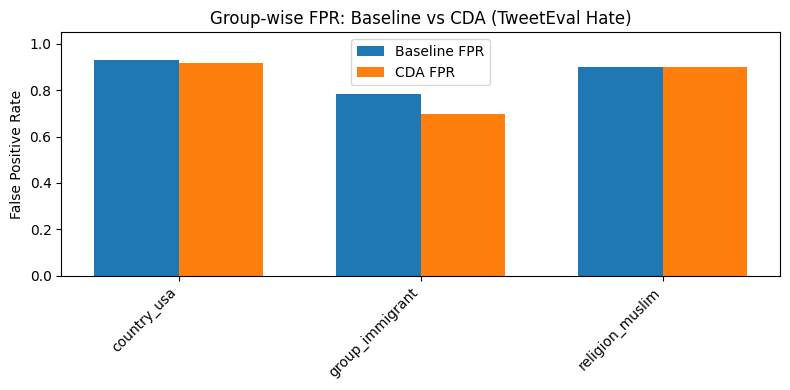

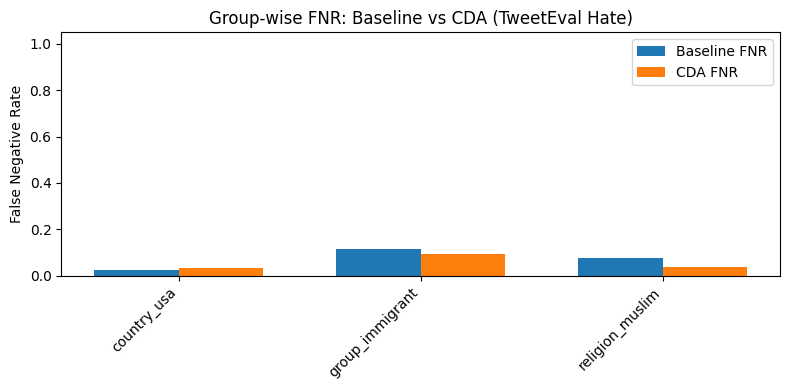

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

test_df_cda = test_df.copy()
test_df_cda["groups"] = test_df_cda["text"].apply(find_groups)
test_df_cda["y_true"] = y_true
test_df_cda["y_pred"] = y_pred_cda
group_stats_cda = group_metrics(test_df_cda, min_count=1)
df_cda = pd.DataFrame(group_stats_cda).T
df_cda = df_cda.rename(columns={
    "num_samples": "num_samples_cda",
    "FPR": "FPR_cda",
    "FNR": "FNR_cda",
})

df_groups = df_base.join(df_cda[["FPR_cda", "FNR_cda"]], how="outer")
df_groups = df_groups.fillna(0.0)
MIN_N = 20
df_plot = df_groups[df_groups["num_samples"] >= MIN_N].copy()

print("=== Group-wise FPR/FNR (Baseline vs CDA) ===")
display(df_plot[["num_samples", "FPR_base", "FPR_cda", "FNR_base", "FNR_cda"]])


df_plot2 = df_plot.copy()
df_plot2 = df_plot[df_plot.index != "country_mexico"].copy()
eps = 0.0  
for col in ["FPR_base", "FPR_cda", "FNR_base", "FNR_cda"]:
    plot_col = col + "_plot"
    df_plot2[plot_col] = df_plot2[col].replace(0.0, eps)

print("\nPlot data:")
display(df_plot2[["num_samples", "FPR_base", "FPR_cda", "FNR_base", "FNR_cda"]])

groups = df_plot2.index.tolist()
x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, df_plot2["FPR_base_plot"], width, label="Baseline FPR")
plt.bar(x + width/2, df_plot2["FPR_cda_plot"],   width, label="CDA FPR")
plt.xticks(x, groups, rotation=45, ha="right")
plt.ylabel("False Positive Rate")
plt.title("Group-wise FPR: Baseline vs CDA (TweetEval Hate)")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, df_plot2["FNR_base_plot"], width, label="Baseline FNR")
plt.bar(x + width/2, df_plot2["FNR_cda_plot"],   width, label="CDA FNR")
plt.xticks(x, groups, rotation=45, ha="right")
plt.ylabel("False Negative Rate")
plt.title("Group-wise FNR: Baseline vs CDA (TweetEval Hate)")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()
